In [8]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [16]:
from src.datasets.multi_season_dataset import build_multi_season_dataset

raw_X_2026, raw_y_2026, final_team_states_2026 = build_multi_season_dataset(
    seasons=[2026]
)

print("raw_X_2026:", raw_X_2026.shape)
print("raw_y_2026:", raw_y_2026.shape)

Starting season 2026...
Finished season 2026: 5426 rows built, 221 skipped, 5647 raw games

All seasons complete.
Seasons processed: 1
Total rows built: 5426
Total games skipped: 221
Total raw games: 5647
All row-count checks passed.
raw_X_2026: (5426, 131)
raw_y_2026: (5426,)


In [17]:
import json

from src.preprocessing.preprocess import preprocess_X

# Preprocess 2026 without symmetrization
X_2026 = preprocess_X(
    raw_X_2026,
    prefix1="team_1_",
    prefix2="team_2_",
    diff_suffix="_diff",
    drop_base_features=True,
)

# Load the exact feature set used in the original model
with open("../../artifacts/feature_columns.json") as f:
    feature_columns = json.load(f)

# Keep only those selected features
X_2026 = X_2026[feature_columns]

y_2026 = raw_y_2026.copy()

print("X_2026:", X_2026.shape)
print("y_2026:", y_2026.shape)

--- Calculating Differentials ---
Successfully computed differentials for 62 base features:
['games_played', 'wins', 'losses', 'win_pct', 'ppg', 'papg', 'fg_pct', 'fg3_pct', 'ft_pct', 'off_rebounds_pg', 'def_rebounds_pg', 'assists_pg', 'turnovers_pg', 'steals_pg', 'blocks_pg', 'personal_fouls_pg', 'home_win_pct', 'away_win_pct', 'neutral_win_pct', 'last_5_games_played', 'last_5_win_pct', 'last_5_ppg', 'last_5_papg', 'last_5_fg_pct', 'last_5_fg3_pct', 'last_5_ft_pct', 'last_5_off_rebounds_pg', 'last_5_def_rebounds_pg', 'last_5_assists_pg', 'last_5_turnovers_pg', 'last_5_steals_pg', 'last_5_blocks_pg', 'last_5_personal_fouls_pg', 'last_5_avg_opponent_win_pct', 'last_5_avg_opponent_point_diff_pg', 'last_10_games_played', 'last_10_win_pct', 'last_10_ppg', 'last_10_papg', 'last_10_fg_pct', 'last_10_fg3_pct', 'last_10_ft_pct', 'last_10_off_rebounds_pg', 'last_10_def_rebounds_pg', 'last_10_assists_pg', 'last_10_turnovers_pg', 'last_10_steals_pg', 'last_10_blocks_pg', 'last_10_personal_fouls_p

In [19]:
old_X_test = pd.read_csv("../../data/X_test.csv")
old_y_test = pd.read_csv("../../data/y_test.csv").squeeze()

print("New non-symmetrized 2026:")
print("X:", X_2026.shape)
print("y:", y_2026.shape)

print("\nOld symmetrized test:")
print("X:", old_X_test.shape)
print("y:", old_y_test.shape)

print("\nExpected old test rows:", 2 * len(X_2026))
print("Actually doubled:", len(old_X_test) == 2 * len(X_2026))

New non-symmetrized 2026:
X: (5426, 33)
y: (5426,)

Old symmetrized test:
X: (10852, 33)
y: (10852,)

Expected old test rows: 10852
Actually doubled: True


In [20]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

X_train = pd.read_csv("../../data/X_train.csv")
y_train = pd.read_csv("../../data/y_train.csv").squeeze()

logistic_regression = LogisticRegression(
    C=0.1,
    solver="lbfgs",
    max_iter=10000
)

logistic_regression.fit(X_train, y_train)

print("Train shape:", X_train.shape)
print("2026 shape:", X_2026.shape)
print("Columns match:", X_train.columns.equals(X_2026.columns))

Train shape: (227972, 33)
2026 shape: (5426, 33)
Columns match: True


In [22]:
y_pred = logistic_regression.predict(X_2026)

y_prob = logistic_regression.predict_proba(X_2026)

p_team_2 = y_prob[:, 0]
p_team_1 = y_prob[:, 1]

In [23]:
print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)
print("y_2026:", y_2026.shape)

print("\nFirst 5 predictions:", y_pred[:5])
print("First 5 probabilities:")
print(y_prob[:5])

Predictions: (5426,)
Probabilities: (5426, 2)
y_2026: (5426,)

First 5 predictions: [1 1 0 1 1]
First 5 probabilities:
[[0.01528471 0.98471529]
 [0.00770972 0.99229028]
 [0.99276094 0.00723906]
 [0.0757044  0.9242956 ]
 [0.00105552 0.99894448]]


In [24]:
results_2026 = raw_X_2026.copy()

results_2026["y_true"] = y_2026.to_numpy()
results_2026["y_pred"] = y_pred

results_2026["p_team_1"] = p_team_1
results_2026["p_team_2"] = p_team_2

results_2026["correct"] = (
    results_2026["y_true"] == results_2026["y_pred"]
)

results_2026.head()

,Season,DayNum,team_1_id,team_1_name,team_1_games_played,team_1_wins,team_1_losses,team_1_win_pct,team_1_ppg,team_1_papg,...,team_2_ft_attempt_rate,team_2_turnover_to_assist_ratio,team_2_avg_opponent_win_pct,team_2_avg_opponent_point_diff_pg,team_1_location,y_true,y_pred,p_team_1,p_team_2,correct
0,2026,2,1208,Georgia,1,1,0,1.0,104.0,59.0,...,0.196429,1.285714,0.0,0.0,1,1,1,0.984715,0.015285,True
1,2026,2,1266,Marquette,1,1,0,1.0,80.0,53.0,...,0.347826,1.200000,0.0,0.0,1,1,1,0.992290,0.007710,True
2,2026,3,1176,Denver,1,0,1,0.0,73.0,84.0,...,0.540984,0.666667,0.0,0.0,-1,0,0,0.007239,0.992761,True
3,2026,3,1260,Loyola-Chicago,1,1,0,1.0,91.0,88.0,...,0.216667,0.818182,0.0,0.0,1,0,1,0.924296,0.075704,False
4,2026,3,1401,Texas A&M,1,1,0,1.0,98.0,68.0,...,0.288136,2.285714,0.0,0.0,1,1,1,0.998944,0.001056,True


In [25]:
game_results = results_2026[
    [
        "Season",
        "DayNum",
        "team_1_name",
        "team_2_name",
        "team_1_location",
        "y_true",
        "y_pred",
        "p_team_1",
        "p_team_2",
        "correct",
    ]
].copy()

game_results.head(10)

,Season,DayNum,team_1_name,team_2_name,team_1_location,y_true,y_pred,p_team_1,p_team_2,correct
0,2026,2,Georgia,MD E Shore,1,1,1,0.984715,0.015285,True
1,2026,2,Marquette,Southern Univ,1,1,1,0.992290,0.007710,True
2,2026,3,Denver,Washington,-1,0,0,0.007239,0.992761,True
3,2026,3,Loyola-Chicago,Mercyhurst,1,0,1,0.924296,0.075704,False
4,2026,3,Texas A&M,TX Southern,1,1,1,0.998944,0.001056,True
5,2026,3,St Francis PA,TCU,-1,0,0,0.027461,0.972539,True
6,2026,3,Chicago St,St Louis,-1,0,0,0.013911,0.986089,True
7,2026,3,Alcorn St,South Alabama,-1,0,0,0.047635,0.952365,True
8,2026,3,Bethune-Cookman,Miami FL,-1,0,0,0.129031,0.870969,True
9,2026,3,Jackson St,Louisville,-1,0,0,0.000133,0.999867,True


In [26]:
game_results["actual_winner"] = np.where(
    game_results["y_true"] == 1,
    game_results["team_1_name"],
    game_results["team_2_name"],
)

game_results["predicted_winner"] = np.where(
    game_results["y_pred"] == 1,
    game_results["team_1_name"],
    game_results["team_2_name"],
)

accuracy = game_results["correct"].mean()

print(f"2026 Accuracy: {accuracy:.2%}")

2026 Accuracy: 71.14%


In [27]:
display_cols = [
    "DayNum",
    "team_1_name",
    "team_2_name",
    "actual_winner",
    "predicted_winner",
    "p_team_1",
    "p_team_2",
    "correct",
]

game_results[display_cols].head(10)

,DayNum,team_1_name,team_2_name,actual_winner,predicted_winner,p_team_1,p_team_2,correct
0,2,Georgia,MD E Shore,Georgia,Georgia,0.984715,0.015285,True
1,2,Marquette,Southern Univ,Marquette,Marquette,0.992290,0.007710,True
2,3,Denver,Washington,Washington,Washington,0.007239,0.992761,True
3,3,Loyola-Chicago,Mercyhurst,Mercyhurst,Loyola-Chicago,0.924296,0.075704,False
4,3,Texas A&M,TX Southern,Texas A&M,Texas A&M,0.998944,0.001056,True
5,3,St Francis PA,TCU,TCU,TCU,0.027461,0.972539,True
6,3,Chicago St,St Louis,St Louis,St Louis,0.013911,0.986089,True
7,3,Alcorn St,South Alabama,South Alabama,South Alabama,0.047635,0.952365,True
8,3,Bethune-Cookman,Miami FL,Miami FL,Miami FL,0.129031,0.870969,True
9,3,Jackson St,Louisville,Louisville,Louisville,0.000133,0.999867,True


In [28]:
game_results["game_in_day"] = (
    game_results
    .groupby("DayNum")
    .cumcount() + 1
)

game_results[
    ["DayNum", "game_in_day", "team_1_name", "team_2_name", "correct"]
].head(15)

,DayNum,game_in_day,team_1_name,team_2_name,correct
0,2,1,Georgia,MD E Shore,True
1,2,2,Marquette,Southern Univ,True
2,3,1,Denver,Washington,True
3,3,2,Loyola-Chicago,Mercyhurst,False
4,3,3,Texas A&M,TX Southern,True
5,3,4,St Francis PA,TCU,True
6,3,5,Chicago St,St Louis,True
7,3,6,Alcorn St,South Alabama,True
8,3,7,Bethune-Cookman,Miami FL,True
9,3,8,Jackson St,Louisville,True


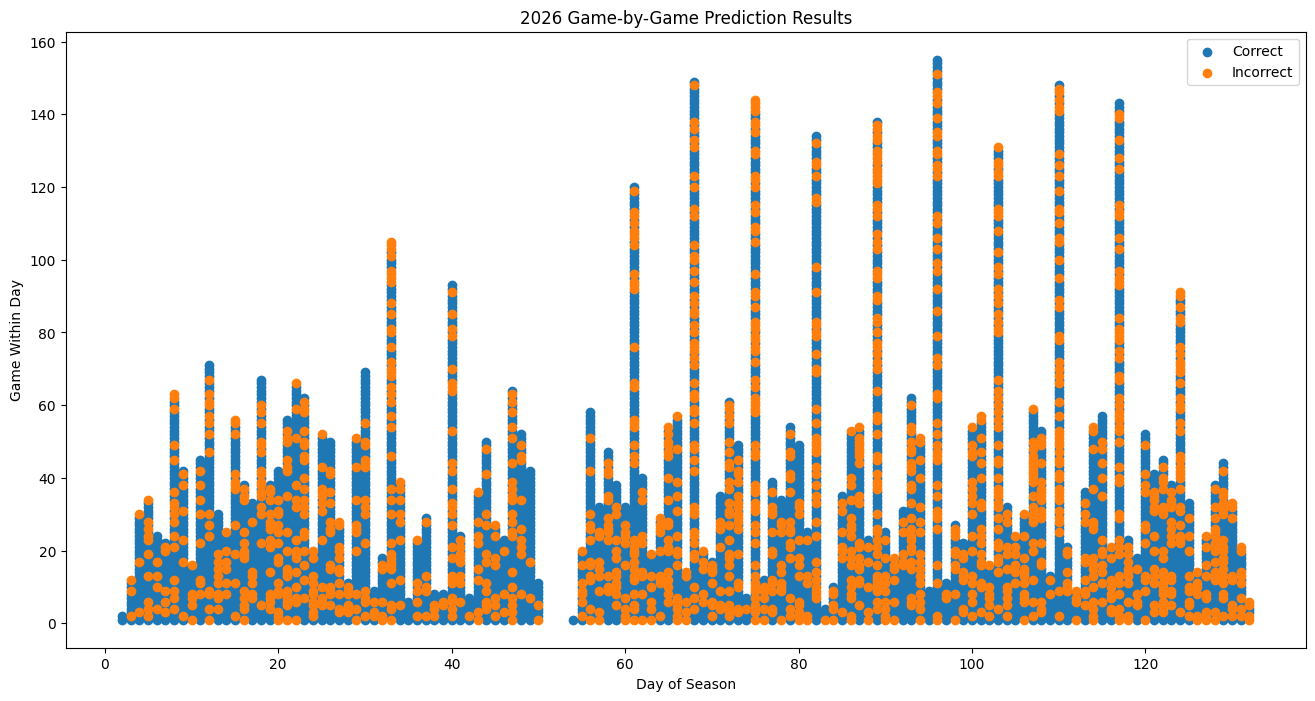

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

plt.scatter(
    game_results.loc[game_results["correct"], "DayNum"],
    game_results.loc[game_results["correct"], "game_in_day"],
    label="Correct"
)

plt.scatter(
    game_results.loc[~game_results["correct"], "DayNum"],
    game_results.loc[~game_results["correct"], "game_in_day"],
    label="Incorrect"
)

plt.xlabel("Day of Season")
plt.ylabel("Game Within Day")
plt.title("2026 Game-by-Game Prediction Results")
plt.legend()

plt.show()

Counts:
correct
True     3860
False    1566
Name: count, dtype: int64

Percentages:
correct
True     71.14
False    28.86
Name: proportion, dtype: float64


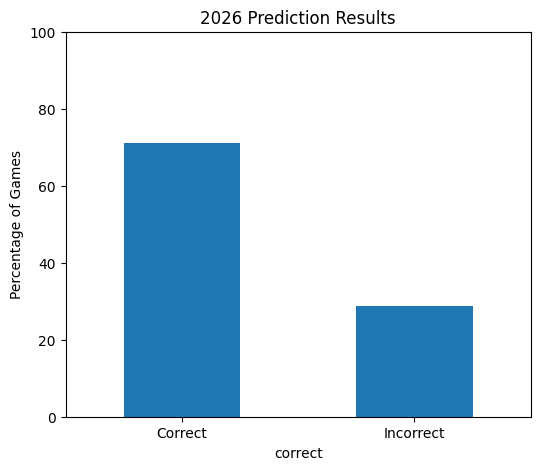

In [42]:
counts = game_results["correct"].value_counts()
percentages = game_results["correct"].value_counts(normalize=True) * 100

print("Counts:")
print(counts)

print("\nPercentages:")
print(percentages.round(2))

plt.figure(figsize=(6, 5))

percentages.plot(kind="bar")

plt.ylabel("Percentage of Games")
plt.title("2026 Prediction Results")

plt.xticks(
    ticks=[0, 1],
    labels=["Correct", "Incorrect"],
    rotation=0
)

plt.ylim(0, 100)
plt.show()

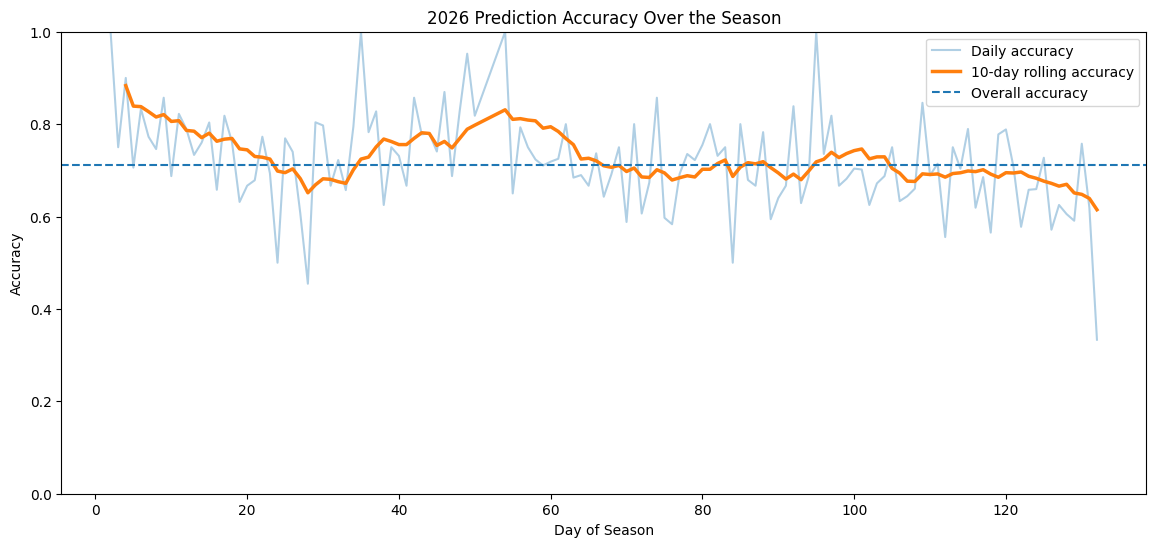

In [30]:
daily_accuracy = (
    game_results
    .groupby("DayNum")["correct"]
    .mean()
)

rolling_accuracy = daily_accuracy.rolling(
    window=10,
    min_periods=3
).mean()

plt.figure(figsize=(14, 6))

plt.plot(daily_accuracy.index, daily_accuracy.values, alpha=0.35, label="Daily accuracy")
plt.plot(rolling_accuracy.index, rolling_accuracy.values, linewidth=2.5, label="10-day rolling accuracy")

plt.axhline(
    game_results["correct"].mean(),
    linestyle="--",
    label="Overall accuracy"
)

plt.xlabel("Day of Season")
plt.ylabel("Accuracy")
plt.title("2026 Prediction Accuracy Over the Season")
plt.ylim(0, 1)
plt.legend()

plt.show()

In [31]:
game_results["min_games_played"] = results_2026[
    ["team_1_games_played", "team_2_games_played"]
].min(axis=1)

In [32]:
accuracy_by_games = (
    game_results
    .groupby("min_games_played")["correct"]
    .agg(["mean", "count"])
)

accuracy_by_games.head(20)

,mean,count
min_games_played,,
1,0.803030,198
2,0.750000,192
3,0.740933,193
4,0.732620,187
5,0.734375,192
6,0.719212,203
7,0.710383,183
8,0.767956,181
9,0.733696,184


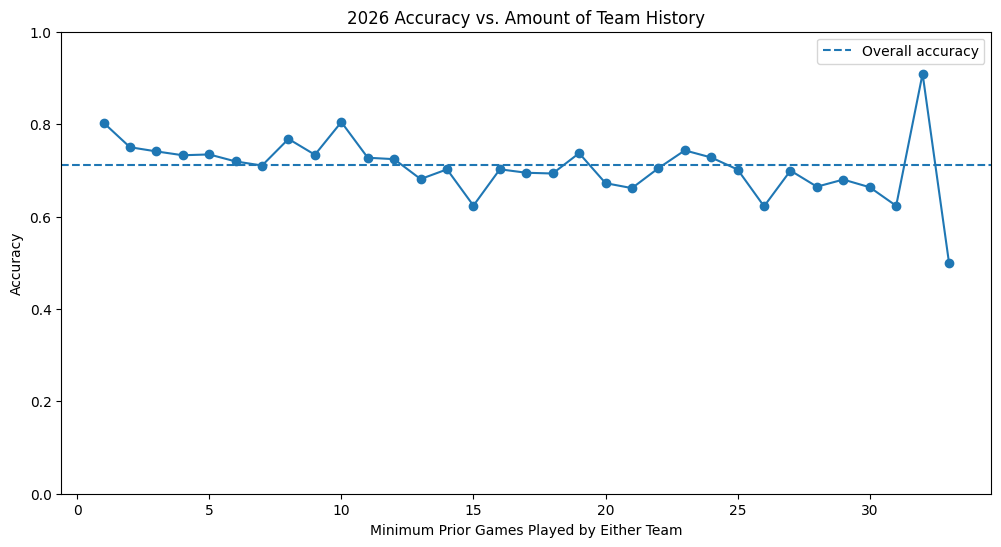

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(
    accuracy_by_games.index,
    accuracy_by_games["mean"],
    marker="o"
)

plt.axhline(
    game_results["correct"].mean(),
    linestyle="--",
    label="Overall accuracy"
)

plt.xlabel("Minimum Prior Games Played by Either Team")
plt.ylabel("Accuracy")
plt.title("2026 Accuracy vs. Amount of Team History")
plt.ylim(0, 1)
plt.legend()

plt.show()

In [34]:
game_results["confidence"] = np.maximum(
    game_results["p_team_1"],
    game_results["p_team_2"]
)

In [35]:
game_results["confidence_bin"] = pd.cut(
    game_results["confidence"],
    bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_results = (
    game_results
    .groupby("confidence_bin", observed=True)["correct"]
    .agg(["mean", "count"])
)

confidence_results

,mean,count
confidence_bin,,
"(0.5, 0.6]",0.564268,1237
"(0.6, 0.7]",0.609737,1253
"(0.7, 0.8]",0.723035,1094
"(0.8, 0.9]",0.821161,1068
"(0.9, 1.0]",0.943152,774


In [36]:
calibration = (
    game_results
    .groupby("confidence_bin", observed=True)
    .agg(
        avg_confidence=("confidence", "mean"),
        actual_accuracy=("correct", "mean"),
        games=("correct", "size"),
    )
)

calibration["calibration_error"] = (
    calibration["actual_accuracy"] - calibration["avg_confidence"]
)

calibration

,avg_confidence,actual_accuracy,games,calibration_error
confidence_bin,,,,
"(0.5, 0.6]",0.550341,0.564268,1237,0.013928
"(0.6, 0.7]",0.650018,0.609737,1253,-0.040281
"(0.7, 0.8]",0.749808,0.723035,1094,-0.026774
"(0.8, 0.9]",0.849556,0.821161,1068,-0.028395
"(0.9, 1.0]",0.943598,0.943152,774,-0.000445


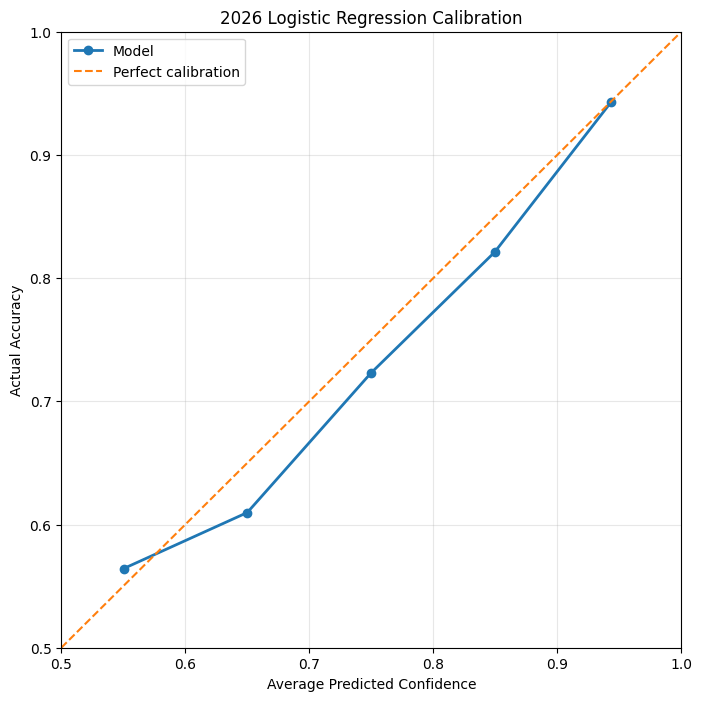

In [37]:
plt.figure(figsize=(8, 8))

plt.plot(
    calibration["avg_confidence"],
    calibration["actual_accuracy"],
    marker="o",
    linewidth=2,
    label="Model"
)

# Perfect calibration reference
plt.plot(
    [0.5, 1.0],
    [0.5, 1.0],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Average Predicted Confidence")
plt.ylabel("Actual Accuracy")
plt.title("2026 Logistic Regression Calibration")

plt.xlim(0.5, 1.0)
plt.ylim(0.5, 1.0)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

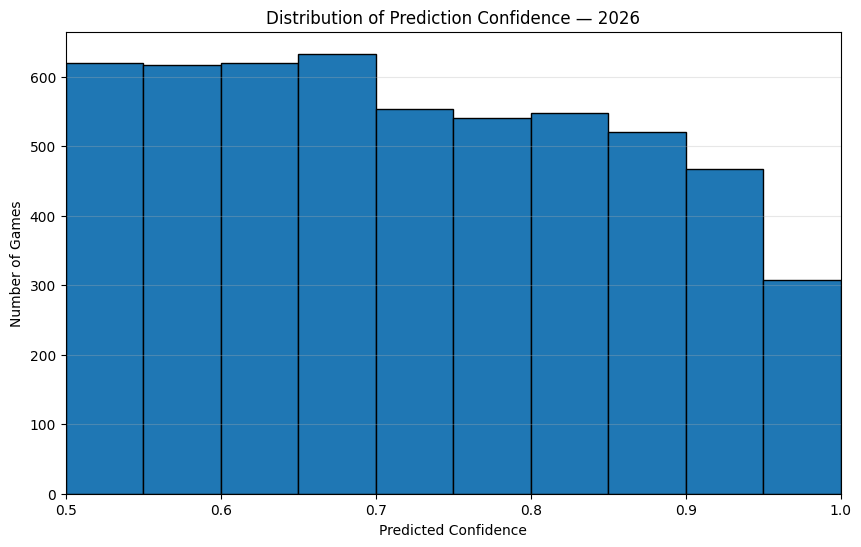

In [38]:
plt.figure(figsize=(10, 6))

plt.hist(
    game_results["confidence"],
    bins=np.arange(0.5, 1.01, 0.05),
    edgecolor="black"
)

plt.xlabel("Predicted Confidence")
plt.ylabel("Number of Games")
plt.title("Distribution of Prediction Confidence — 2026")

plt.xlim(0.5, 1.0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [39]:
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in thresholds:
    subset = game_results[game_results["confidence"] >= threshold]

    threshold_results.append({
        "confidence_threshold": threshold,
        "games": len(subset),
        "coverage": len(subset) / len(game_results),
        "accuracy": subset["correct"].mean()
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,confidence_threshold,games,coverage,accuracy
0,0.5,5426,1.000000,0.711390
1,0.6,4189,0.772024,0.754834
2,0.7,2936,0.541098,0.816757
3,0.8,1842,0.339477,0.872421
4,0.9,774,0.142647,0.943152


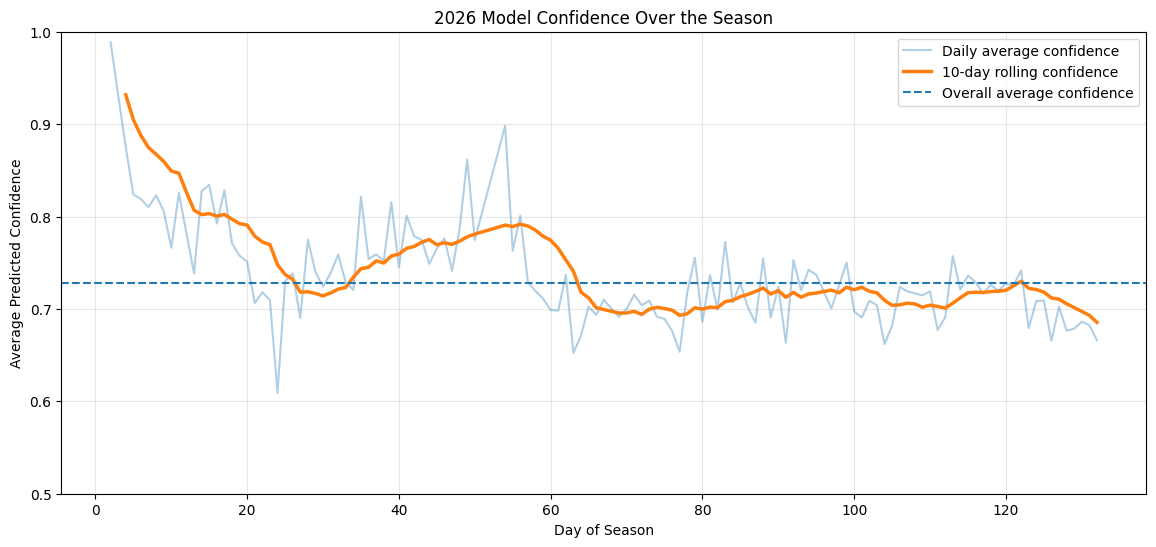

In [40]:
daily_confidence = (
    game_results
    .groupby("DayNum")["confidence"]
    .mean()
)

rolling_confidence = daily_confidence.rolling(
    window=10,
    min_periods=3
).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    daily_confidence.index,
    daily_confidence.values,
    alpha=0.35,
    label="Daily average confidence"
)

plt.plot(
    rolling_confidence.index,
    rolling_confidence.values,
    linewidth=2.5,
    label="10-day rolling confidence"
)

plt.axhline(
    game_results["confidence"].mean(),
    linestyle="--",
    label="Overall average confidence"
)

plt.xlabel("Day of Season")
plt.ylabel("Average Predicted Confidence")
plt.title("2026 Model Confidence Over the Season")
plt.ylim(0.5, 1.0)
plt.legend()
plt.grid(alpha=0.3)

plt.show()